# Healthcare Member Outreach Prioritization Analysis

## Business Problem:

Identify high-risk, high-cost members who are not engaged in care management to prioritize outreach.

📌 Key Findings

Use bullet points:

• High Priority members have the highest cost per member  
• High Priority members are not engaged in care management  
• Low Priority members represent the majority of the population and total spend  
• ER and inpatient utilization is higher among High Priority members  

📌 Business Impact

This model enables care management teams to:

• Prioritize outreach to high-risk, high-cost members  
• Improve care management engagement rates  
• Reduce avoidable inpatient and ER utilization  
• Balance targeted interventions with population-level cost strategies  

This analysis uses a dbt-powered data pipeline to transform raw healthcare data into actionable outreach prioritization insights.

In [11]:
import pandas as pd

df = pd.read_csv("../data/exports/mart_member_outreach_priority.csv")

df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   MEMBER_ID                1000 non-null   int64  
 1   FIRST_NAME               1000 non-null   str    
 2   LAST_NAME                1000 non-null   str    
 3   GENDER                   1000 non-null   str    
 4   STATE                    1000 non-null   str    
 5   EMPLOYER_GROUP           1000 non-null   str    
 6   RISK_LEVEL               1000 non-null   str    
 7   CHRONIC_CONDITION_FLAG   1000 non-null   int64  
 8   TOTAL_INTERACTIONS       1000 non-null   int64  
 9   SUCCESSFUL_INTERACTIONS  1000 non-null   int64  
 10  LAST_INTERACTION_DATE    990 non-null    str    
 11  ENGAGEMENT_STATUS        1000 non-null   str    
 12  SERVICE_MONTH            1000 non-null   str    
 13  TOTAL_CLAIMS             1000 non-null   int64  
 14  TOTAL_ALLOWED_AMOUNT     1000 non-nu

In [12]:
df['OUTREACH_PRIORITY'].value_counts(normalize=True)

OUTREACH_PRIORITY
Low Priority       0.805
Medium Priority    0.117
High Priority      0.078
Name: proportion, dtype: float64

In [13]:
df.groupby('OUTREACH_PRIORITY')[['TOTAL_ALLOWED_AMOUNT','TOTAL_PAID_AMOUNT']].mean().round(2)

,TOTAL_ALLOWED_AMOUNT,TOTAL_PAID_AMOUNT
OUTREACH_PRIORITY,,
High Priority,14276.22,12532.52
Low Priority,10356.22,8871.41
Medium Priority,10472.94,8882.90


In [14]:
df.groupby('OUTREACH_PRIORITY')[['IP_CLAIMS','ER_CLAIMS','OP_CLAIMS','RX_CLAIMS']].sum()

,IP_CLAIMS,ER_CLAIMS,OP_CLAIMS,RX_CLAIMS
OUTREACH_PRIORITY,,,,
High Priority,24,44,125,44
Low Priority,201,424,947,512
Medium Priority,31,44,111,70


In [15]:
pd.crosstab(df['OUTREACH_PRIORITY'], df['ENGAGEMENT_STATUS'])

ENGAGEMENT_STATUS,Engaged,Not Engaged
OUTREACH_PRIORITY,,
High Priority,0,78
Low Priority,716,89
Medium Priority,0,117


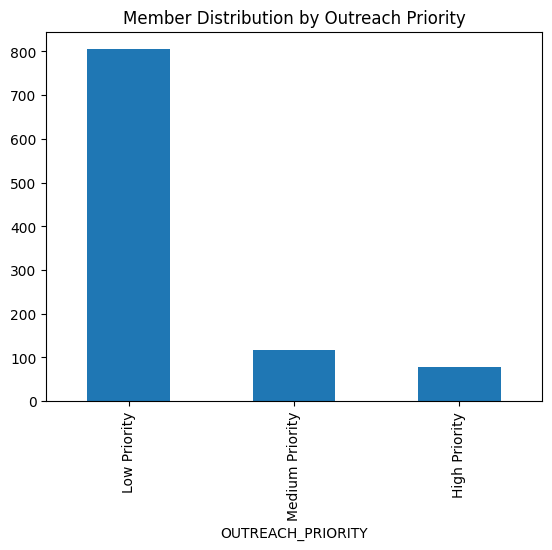

In [16]:
import matplotlib.pyplot as plt

df['OUTREACH_PRIORITY'].value_counts().plot(kind='bar')
plt.title("Member Distribution by Outreach Priority")
plt.show()

In [17]:
df.groupby('OUTREACH_PRIORITY')[['TOTAL_ALLOWED_AMOUNT']].sum()

,TOTAL_ALLOWED_AMOUNT
OUTREACH_PRIORITY,
High Priority,1113545.20
Low Priority,8336754.20
Medium Priority,1225334.41


In [18]:
df.groupby('OUTREACH_PRIORITY')['TOTAL_ALLOWED_AMOUNT'].mean().round(2)

OUTREACH_PRIORITY
High Priority      14276.22
Low Priority       10356.22
Medium Priority    10472.94
Name: TOTAL_ALLOWED_AMOUNT, dtype: float64

In [19]:
total = df['TOTAL_ALLOWED_AMOUNT'].sum()

(df.groupby('OUTREACH_PRIORITY')['TOTAL_ALLOWED_AMOUNT'].sum() / total).round(3)

OUTREACH_PRIORITY
High Priority      0.104
Low Priority       0.781
Medium Priority    0.115
Name: TOTAL_ALLOWED_AMOUNT, dtype: float64